In [1]:
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf
from scipy.signal.windows import tukey
import jax
import jax.numpy as jnp
from astropy.time import Time
from ripple.waveforms import IMRPhenomD, IMRPhenomXAS
from jimgw.single_event.detector import H1, L1
from functools import partial
import sys
# from torch._C import float64

sys.path.append('../../mist-base/GW')
sys.path.append('../../')

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

pf.housestyle_rcparams()

True

In [2]:
defaults = {
    "approximant": "IMRPhenomD",
    "f_min": 20., #40.0,
    "f_max": 1024., #400.0,
    "f_ref": 20.0,
    "notches": [60.0, 120.0, 180.0],
    "notch_width": 0.1,
    "trigger_time": 1126259462.4,
    "pre_trigger_time": 2.0,
    "post_trigger_time": 2.0,
    "data_window": 1000,
    "psd_window":4,
    # "psd_pad": 16.0,
    "ifo": "H1",
    # "tukey_alpha": 0.2,
    "posterior_samples_path": "GW150814_posterior_samples.npz",
}

class Base_GW1501914:
    def __init__(self, settings:dict={}, stoch_mu=True):
        self.settings = settings
        self.stoch = stoch_mu
        self._unpack_settings()
        self._initialise_gw()
        self._load_posterior_samples()
        self._setup_waveform()

    ### METHODS ###
    
    def _unpack_settings(self):
        self.approximant = self.settings.get("approximant", "IMRPhenomD")
        self.f_min = self.settings.get("f_min", 20.)
        self.f_max = self.settings.get("f_max", 1024.)
        self.f_ref = self.settings.get("f_ref", 20.0)
        self.notches = self.settings.get("notches", [60.0, 120.0, 180.0])
        self.notch_width = self.settings.get("notch_width", 0.1)
        self.trigger_time = self.settings.get("trigger_time", 1126259462.4)
        self.pre_trigger_time = self.settings.get("pre_trigger_time", 2.0)
        self.post_trigger_time = self.settings.get("post_trigger_time", 2.0)
        self.data_window = self.settings.get("data_window", 1000)
        self.psd_window = self.settings.get("psd_window", 2)
        # self.psd_pad = self.settings.get("psd_pad", 16.0)
        self.ifo = self.settings.get("ifo", "H1")
        # self.tukey_alpha = self.settings.get("tukey_alpha", 0.2) #### CHANGE THIS ####
        self.posterior_samples_path = self.settings.get(
            "posterior_samples_path", "../../mist-base/GW/GW150814_posterior_samples.npz"
        )
        self.key = jax.random.PRNGKey(42)

    def _initialise_gw(self):
        self.event_time = event_gps('GW150914')
        print(f'Fetching {self.data_window}s of data from {self.ifo}. Will take <4mins.')
        self.gwosc_data = TimeSeries.fetch_open_data(self.ifo, self.event_time-2*self.data_window, 
                                                     self.event_time-self.data_window, sample_rate=4096)
        print(f'Calculating PSD for FFT window length {self.psd_window}s.')
        self.psd = self.gwosc_data.psd(fftlength=self.psd_window)
        self.frequencies = self.psd.frequencies.value
        self.tukey_alpha = 1/self.psd_window

        self.times = self.gwosc_data.times.value - self.trigger_time
        self.duration = self.gwosc_data.duration.value
        self.npts = len(self.gwosc_data)
        self.delta_t = self.gwosc_data.dt.value
        self.epoch = self.duration - self.post_trigger_time
        self.gmst = (
            Time(self.trigger_time, format="gps")
            .sidereal_time("apparent", "greenwich")
            .rad
        )
        if self.ifo == "H1":
            self.detector = H1
        elif self.ifo == "L1":
            self.detector = L1
        
    def _tukey(self, x):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        window = tukey(np.shape(x)[1], alpha=self.tukey_alpha) # shape [nbins]
        return x*np.expand_dims(window,axis=0) # shape [nsamples, nbins]
    
    def whiten(self, x):
        # x is supplied in form [nbins (complex)]
        x = np.array(x)
        return x/np.sqrt(self.psd.data)
    
    def whiten_batch(self,x):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        prefactor = np.expand_dims(np.sqrt(np.array(self.psd.data)), axis=0)
        return x/prefactor
         
    
    def _load_posterior_samples(self):
        # print(f"Loading posterior samples from {self.posterior_samples_path}")
        self.posterior_samples = np.load(self.posterior_samples_path)
        self.parameter_names = [
            "M_c",
            "q",
            "s1_z",
            "s2_z",
            "d_L",
            "t_c",
            "phase_c",
            "iota",
            "ra",
            "dec",
            "psi",
        ]
        for param_name in self.posterior_samples.files:
            if param_name not in self.parameter_names:
                raise ValueError(
                    f"Parameter {param_name} not recognized in posterior file"
                )
        self.posterior_array = np.vstack(
            [self.posterior_samples[name] for name in self.parameter_names]
        ).T
        self.posterior_array[:, 1] = (self.posterior_array[:, 1]) / (
            1.0 + self.posterior_array[:, 1]
        ) ** 2  # q -> eta = q / (1 + q)^2
        self.posterior_array[:, 5] = (
            self.epoch + self.posterior_array[:, 5]
        )  # t_c -> t_c + epoch

    def _setup_waveform(self):
        if self.approximant == "IMRPhenomD":
            self.waveform = IMRPhenomD.gen_IMRPhenomD_hphc
        elif self.approximant == "IMRPhenomXAS":
            self.waveform = IMRPhenomXAS.gen_IMRPhenomXAS_hphc
        else:
            raise ValueError(f"Approximant {self.approximant} not recognized")
    
    ### DATA GETTERS ###

    def _get_noise_td(self, nsamples):
        ref = self.event_time-1.5*self.data_window
        nbins = len(self.gwosc_data.crop(ref-self.psd_window/2, ref+self.psd_window/2))
        alldata_raw = jnp.array(self.gwosc_data)
        max_start_index = alldata_raw.shape[0] - nbins
        start_indices = jax.random.randint(self.key, shape=(nsamples,), minval=0, maxval=max_start_index + 1)
        offsets = jnp.arange(nbins)
        indices = start_indices[:, None] + offsets
        return alldata_raw[indices]
    
    def get_noise_fd(self, nsamples):
        noise_td = self._get_noise_td(nsamples=nsamples)
        noise_td_windowed = self._tukey(noise_td)
        noise_fd_complex = jnp.fft.rfft(noise_td_windowed)*self.gwosc_data.dt
        return self.whiten_batch(noise_fd_complex)
    
    def get_GW150914_td(self):
        return TimeSeries.fetch_open_data(self.ifo, self.event_time-self.psd_window/2, 
                                                     self.event_time+self.psd_window/2, sample_rate=4096)
        
    def get_GW150914_fd(self):
        raw = self.get_GW150914_td().data
        raw_windowed = np.squeeze(self._tukey(np.expand_dims(raw,axis=0)), axis=0)
        raw_fd = np.fft.rfft(raw_windowed)*self.gwosc_data.dt
        return self.whiten(raw_fd)

    ### WAVEFORM GENERATORS ###

    @partial(jax.jit, static_argnums=(0,))
    def call_waveform(self, theta_ripple):
        hp, hc = self.waveform(self.frequencies, theta_ripple, f_ref=self.f_ref)
        return hp, hc
    
    def _fd_theta_batched(self,nsims):
        if not self.stoch:
            choices = np.random.choice(self.posterior_array.shape[0], size=1, replace=True)
            single_param_set = self.posterior_array[choices]
            params_batch = np.tile(single_param_set, (nsims, 1))
            return torch.from_numpy(params_batch)
        else:
            choices = np.random.choice(self.posterior_array.shape[0], size=nsims, replace=True)
            params_batch = self.posterior_array[choices]
            return torch.from_numpy(params_batch)
        
    def _fd_waveform_batched(self, params_batch_tensor):
        params_batch = params_batch_tensor.numpy()
        theta_ripple_batch = params_batch[:, :8]
        ra_batch, dec_batch, psi_batch = params_batch[:, 8], params_batch[:, 9], params_batch[:, 10]
        batched_waveform = jax.vmap(self.call_waveform)
        batched_detector_response = jax.vmap(
            self.detector.fd_response,
            in_axes=(None, {'p': 0, 'c': 0}, {'ra': 0, 'dec': 0, 'psi': 0, 'gmst': None})
        )
        hp_batch, hc_batch = batched_waveform(theta_ripple_batch)
        wf_fd_batch = batched_detector_response(
            self.frequencies,
            {"p": hp_batch, "c": hc_batch},
            {"ra": ra_batch, "dec": dec_batch, "psi": psi_batch, "gmst": self.gmst},
        )
        return self.whiten_batch(wf_fd_batch)
    
    


In [ ]:
class GW_Additive_F(Base_GW1501914):
    def __init__(self, settings: dict = {}, stoch_mu=True, device='cpu', dtype=torch.float64, 
                 bkg=True,bounds=5,fraction=None,sample_fraction=None):
        
        super().__init__(settings, stoch_mu)

        self.device = device
        self.dtype = dtype
        self.bkg = bkg
        self.bounds = bounds
        self.fraction = fraction
        self.sample_fraction = sample_fraction

        self.Nbins = len(self.frequencies)
        self.grid = self.frequencies

        self.dtype_map = {
            torch.float64:torch.complex128,
            torch.float32:torch.complex64,
            torch.float16:torch.complex32
        }
        self.complex_dtype = self.dtype_map.get(self.dtype,torch.complex128)

    def to_type(self, tensr:torch.Tensor) -> torch.Tensor:
        return tensr.to(dtype=self.dtype, device=self.device)
    
    def to_type_complex(self, tensr:torch.Tensor) -> torch.Tensor:
        complex_dtype = self.dtype_map.get(self.dtype,torch.complex128)
        return tensr.to(dtype=complex_dtype, device=self.device)

    def get_theta(self, Nsims: int) -> torch.Tensor:
        if self.bkg:
            output = self._fd_theta_batched(Nsims)
            return self.to_type(output)
        else:
            output = torch.zeros([Nsims, self.Nbins])
            return self.to_type(output)
    
    def get_mu(self, theta: torch.Tensor) -> torch.Tensor:
        mu = torch.tensor(self._fd_waveform_batched(theta))
        return self.to_type_complex(mu)
    
    def get_x_H0(self, mu:torch.Tensor) -> torch.Tensor:
        x_shape = mu.shape
        noise = torch.tensor(self.get_noise_fd(x_shape[0]))
        return mu+noise
    
    def get_ni(self, x: torch.Tensor) -> torch.Tensor:
        xreal = torch.abs(torch.tensor(x)).squeeze(0)
        if self.fraction is None:
            """Standard basis vectors"""
            batch_size, N_bins = xreal.shape
            ni = torch.zeros(batch_size, N_bins, device=self.device, dtype=self.complex_dtype)
            indices = torch.randint(0, N_bins, (batch_size,), device=self.device)
            ni[torch.arange(batch_size), indices] = 1
        else:
            """Fraction of bins are distorted"""
            if self.sample_fraction:
                fr = np.random.uniform(0.01, self.fraction)
            else:   
                fr = self.fraction
            prob = fr*self.Nbins/100
            random_vals = torch.rand_like(xreal)
            ni = (random_vals < prob).type(self.dtype)  # fr% chance
        return ni
    
    def get_epsilon(self, ni: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        xreal = torch.abs(torch.tensor(x)).squeeze(0)
        return (2 * self.bounds * torch.rand(xreal.shape, device=self.device, dtype=self.complex_dtype) - self.bounds) * ni
    
    def get_x_Hi(self, epsilon: torch.Tensor, ni: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return x + epsilon * ni

    def _sample(self, Nsims: int) -> dict:
        sample = {} 

        Theta = self.get_theta(Nsims) ## note i have built in the bkg method to theta to make this cleaner
        Mu = self.get_mu(Theta)
        X0 = self.get_x_H0(Mu)
        Ni = self.get_ni(X0)
        Epsilon = self.get_epsilon(Ni, X0)
        Xi = self.get_x_Hi(Epsilon, Ni, X0)

        sample.update({'theta':Theta,'mu':Mu, 'x0': X0, 
                       'epsilon': Epsilon, 'ni': Ni, 'xi': Xi})
    
        return sample
    
    def _resample(self, sample: dict) -> dict:
        sample['x0'] = self.get_x_H0(sample['mu'])
        sample['ni'] = self.get_ni(sample['x0'])
        sample['epsilon'] = self.get_epsilon(sample['ni'], sample['x0'])
        sample['xi'] = self.get_x_Hi(sample['epsilon'], sample['ni'], sample['x0'])
        return sample
    
    def sample(self, Nsims: int = 1) -> dict:
        sample = self._sample(Nsims)
        return sample


class GW_Additive_F_Correlated(GW_Additive_F):
    def __init__(self, settings: dict = {}, stoch_mu=True, device='cpu', 
                 dtype=torch.float64, bkg=True, bounds=5, fraction=None, 
                 sample_fraction=None, 
                 correlation_scales = 2**torch.linspace(0, 5, 6).int()):
        super().__init__(settings, stoch_mu, device, dtype, bkg, bounds, 
                         fraction, sample_fraction)
        
        self.correlation_scales = correlation_scales

    def _conv1d(self, ni: torch.Tensor, c: int) -> torch.Tensor:
        w = torch.linspace(-3, 3, 1+int(c)*2, device=ni.device, dtype=ni.complex_dtype).unsqueeze(0).unsqueeze(0)
        w = torch.exp(-0.5*w**2)
        w = w/w.max() # Normalize maximum to 1
        y = torch.nn.functional.conv1d(ni.unsqueeze(1), w.to(ni.dtype), padding = int(c)).squeeze(1)
        return y
    
    def get_correlation(self, ni, epsilon) -> torch.Tensor:
        if isinstance(self.bounds, float) or isinstance(self.bounds, int):
            cc = torch.stack([self._conv1d(ni*epsilon, int(c)) for c in self.correlation_scales], axis=1)
        elif len(self.bounds)==len(self.correlation_scales):
            cc = torch.stack([self._conv1d(ni*epsilon[:, i_c], int(c)) for i_c, c in enumerate(self.correlation_scales)], axis=1)
        return cc
    
    def get_epsilon(self, ni: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        if isinstance(self.bounds, float) or isinstance(self.bounds, int):
            eps = (2 * self.bounds * torch.rand(x.shape, device=self.device, dtype=self.complex_dtype) - self.bounds) * ni
        elif len(self.bounds)==len(self.correlation_scales):
            eps = (2 * self.bounds.unsqueeze(0).unsqueeze(2) * 
                   torch.rand(x.shape, device=self.device, dtype=self.complex_dtype
                              ).unsqueeze(1).to(self.complex_dtype) - self.bounds.unsqueeze(0).unsqueeze(2)
                              ) * ni.unsqueeze(1)
        return eps.to(self.dtype)
        
    def get_x_Hi(self, cni: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return x +  cni
    
    def _sample(self, Nsims: int) -> dict:
        sample = {}

        theta = self.get_theta(Nsims)
        mu = self.get_mu(theta)
        x0 = self.get_x_H0(mu)
        
        ni = self.get_ni(x0)
        epsilon = self.get_epsilon(ni, x0)
        cni = self.get_correlation(ni, epsilon)
        xi = self.get_x_Hi(cni, x0.unsqueeze(1))

        sample.update({'theta':theta, 'mu':mu,
                       'x0': x0, 'epsilon': epsilon, 
                       'ni': ni, 'cni': cni, 'xi': xi})
        return sample


In [4]:
gw = Base_GW1501914()

Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 2s.


True

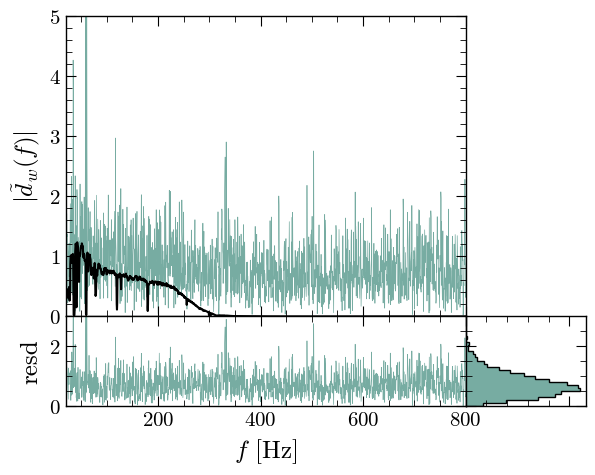

In [5]:
noise = gw.get_noise_fd(4)[0]
theta = gw._fd_theta_batched(4)
mu = gw._fd_waveform_batched(theta)[0]
f = gw.frequencies

fig, ax = pf.create_plot()
plt.setp(ax.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,.3), sharex=ax)
ax3 = fig.add_axes((1,-.3,.3,.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
axes = [ax,ax2,ax3]

ax.plot(f, np.abs(noise+mu), color='#77aca2', lw=0.5)
ax.plot(f,np.abs(mu), color='k')

ax2.plot(f, np.abs(noise), color='#77aca2', lw=0.5)

ax3.hist(np.abs(noise),bins=np.linspace(0,5,50), histtype='step', orientation='horizontal', density=True, color='k')
ax3.hist(np.abs(noise),bins=np.linspace(0,5,50), orientation='horizontal', density=True, color='#77aca2')

ax2.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$|\tilde{d}_w(f)|$')
ax.set_xlim([20,800])
ax.set_ylim([0,5])
ax2.set_ylim([0,3])

ax2.set_ylabel('resd')

pf.fix_plot(axes)



True

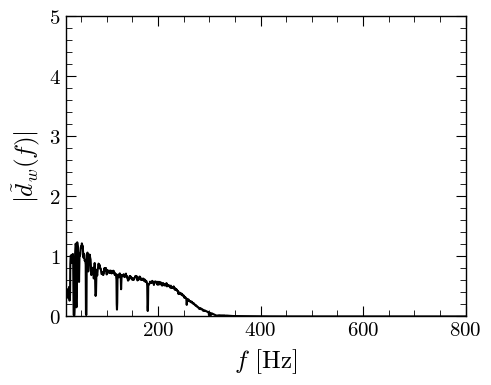

In [6]:
fig2, secax = pf.create_plot()

secax.set_xlabel(r'$f$ [Hz]')
secax.set_ylabel(r'$|\tilde{d}_w(f)|$')
secax.set_xlim([20,800])
secax.set_ylim([0,5])


secax.plot(f,np.abs(mu), color='k')
pf.fix_plot([secax])

True

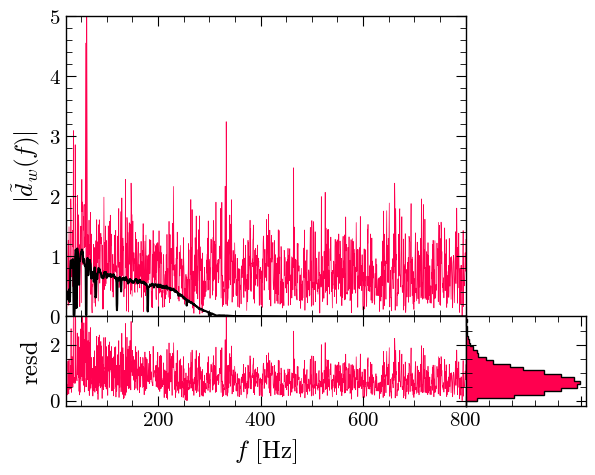

In [7]:
noise = gw.get_noise_fd(4)[0]
theta = gw._fd_theta_batched(4)
mu = gw._fd_waveform_batched(theta)[0]
f = gw.frequencies

fig, ax = pf.create_plot()
plt.setp(ax.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,.3), sharex=ax)
ax3 = fig.add_axes((1,-.3,.3,.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
axes = [ax,ax2,ax3]


gw150914 = gw.get_GW150914_fd()
ax.plot(f, np.abs(gw150914), lw=0.5, color='#ff004f')
ax.plot(f,np.abs(mu), color='k')

noise = np.abs(gw150914-mu)
ax2.plot(f, noise, color='#ff004f', lw=0.5)

ax3.hist(noise,bins=np.linspace(-1,5,50), histtype='step', orientation='horizontal', density=True, color='k')
ax3.hist(noise,bins=np.linspace(-1,5,50), orientation='horizontal', density=True, color='#ff004f')

ax2.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$|\tilde{d}_w(f)|$')
ax.set_xlim([20,800])
ax.set_ylim([0,5])
ax2.set_ylim([-.2,3])

ax2.set_ylabel('resd')

pf.fix_plot(axes)

# np.savez('../week10/gw1509data.npz',f=f,gw150914=gw150914)


In [8]:
quantiles = np.array([0.05199686, 0.2145543,  0.58780088, 1.17737921, 1.91882754,
 2.75067576, 3.63463655])

quantiles_long = np.array([7.11978022e-04, 7.96148769e-03, 5.19968566e-02, 2.14554300e-01,
 5.87800876e-01, 1.17737921e+00, 1.91882754e+00, 2.75067576e+00,
 3.63463655e+00, 4.55164698e+00, 5.49045819e+00])

simulator = GW_Additive_F(fraction=0.005)

Fetching 1000s of data from H1. Will take <4mins.


Calculating PSD for FFT window length 2s.


/tmp/ipykernel_1438865/114564452.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xreal = torch.abs(torch.tensor(x)).squeeze(0)
/tmp/ipykernel_1438865/114564452.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xreal = torch.abs(torch.tensor(x)).squeeze(0)
/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/numpy/ma/core.py:2896: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
/tmp/ipykernel_1438865/676464047.py:49

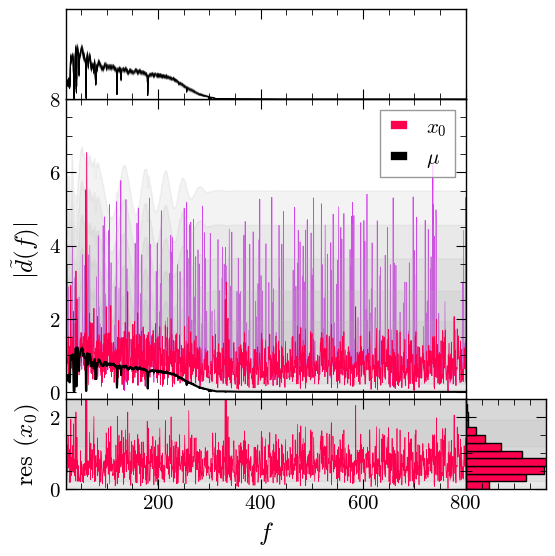

In [12]:
# samples = simulator.sample(124)  
obs = simulator.sample(1)
# simulator.get_theta(100)

test = simulator.sample(1)

pf.housestyle_rcparams()
fig, ax1 = pf.create_plot()

plt.setp(ax1.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,0.3), sharex=ax1)
ax3 = fig.add_axes((1,-.3,0.2,0.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
ax4 = fig.add_axes((0,1,1,0.3), sharex=ax1)
plt.setp(ax4.get_xticklabels(), visible=False)

ax1.plot(simulator.grid,torch.abs(test['x0'][0]), label=r'$x_0$', color='#ff004f', lw=0.5)
ax1.plot(simulator.grid,torch.abs(test['mu'][0]), label=r'$\mu$', color='black')
ax1.set_ylabel(r'$|\tilde{d}(f)|$')
ax1.set_ylim([-.2,8])
ax1.legend(loc='upper right')
ax1.set_xlim(20, 800)


resd = torch.abs(test['x0'][0]-test['mu'][0])
ax2.plot(simulator.grid,resd, color='#ff004f', lw=0.5)
ax2.set_xlabel(r'$f$')
ax2.set_ylabel(r'res ($x_0$)')
ax2.set_ylim([0,2.5])
for i in range(1,6):
    ax1.fill_between(simulator.grid, quantiles_long[i]+torch.abs(test['mu'][0]), quantiles_long[-i]+test['mu'][0],  color='#b0b0b0', alpha=0.15)
    ax2.fill_between(simulator.grid, quantiles_long[i], quantiles_long[-i],  color='#b0b0b0', alpha=0.15)
    ax3.fill_between(simulator.grid, quantiles_long[i], quantiles_long[-i],  color='#b0b0b0', alpha=0.15)

ax3.hist(resd, orientation='horizontal', bins=torch.linspace(0,3, 15), edgecolor='black', color='#ff004f', density=True)
ax3.set_xlim([0,1])

for i in range(100):
    ax4.plot(simulator.grid,torch.abs(simulator.sample(1)['mu'][0]), lw=0.5, color='black', alpha=0.05)

ax4.set_yticks([])
ax4.set_ylim([0,2])
ax4.set_visible(False if simulator.bkg==False else True)
pf.fix_plot([ax1,ax2, ax3,ax4])
for i in range(2):
    if i==1:
        ax1.plot(simulator.grid,torch.abs(test['xi'][0]), label=r'$x_i$', color="#d931f3", lw=0.5, zorder=-1)
    plt.tight_layout()
    plt.savefig(f'figs/output{i}.png', dpi=900, bbox_inches='tight')

/tmp/ipykernel_1438865/114564452.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xreal = torch.abs(torch.tensor(x)).squeeze(0)
/tmp/ipykernel_1438865/114564452.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xreal = torch.abs(torch.tensor(x)).squeeze(0)


torch.Size([2, 4097])

In [47]:
quantiles = np.array([0.05199686, 0.2145543,  0.58780088, 1.17737921, 1.91882754,
 2.75067576, 3.63463655])

quantiles_long = np.array([7.11978022e-04, 7.96148769e-03, 5.19968566e-02, 2.14554300e-01,
 5.87800876e-01, 1.17737921e+00, 1.91882754e+00, 2.75067576e+00,
 3.63463655e+00, 4.55164698e+00, 5.49045819e+00])

c_scales = torch.tensor([200, 600, 1000]).int()
simulator = GW_Additive_F_Correlated(correlation_scales=c_scales)


Fetching 1000s of data from H1. Will take <4mins.


Calculating PSD for FFT window length 2s.


/tmp/ipykernel_1410459/1391099802.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xreal = torch.abs(torch.tensor(x))
/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/data/tgh35/summer25/cam_venv/lib/python3.11/site-packages/numpy/ma/core.py:2896: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
/tmp/ipykernel_1410459/1559813514.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be

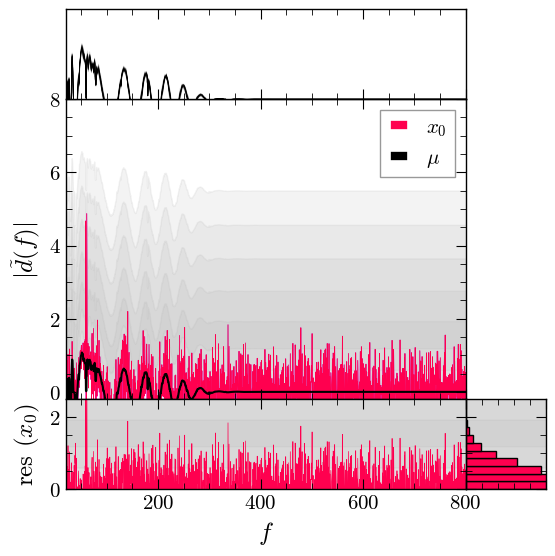

In [48]:

# samples = simulator.sample(124)  
obs = simulator.sample(1)
# simulator.get_theta(100)

test = simulator.sample(1)

pf.housestyle_rcparams()
fig, ax1 = pf.create_plot()

plt.setp(ax1.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,0.3), sharex=ax1)
ax3 = fig.add_axes((1,-.3,0.2,0.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
ax4 = fig.add_axes((0,1,1,0.3), sharex=ax1)
plt.setp(ax4.get_xticklabels(), visible=False)

ax1.plot(simulator.grid,test['x0'][0], label=r'$x_0$', color='#ff004f', lw=0.5)
ax1.plot(simulator.grid,test['mu'][0], label=r'$\mu$', color='black')
ax1.set_ylabel(r'$|\tilde{d}(f)|$')
ax1.set_ylim([-.2,8])
ax1.legend(loc='upper right')
ax1.set_xlim(20, 800)


resd = test['x0'][0]-test['mu'][0]
ax2.plot(simulator.grid,resd, color='#ff004f', lw=0.5)
ax2.set_xlabel(r'$f$')
ax2.set_ylabel(r'res ($x_0$)')
ax2.set_ylim([0,2.5])
for i in range(1,6):
    ax1.fill_between(simulator.grid, quantiles_long[i]+test['mu'][0], quantiles_long[-i]+test['mu'][0],  color='#b0b0b0', alpha=0.15)
    ax2.fill_between(simulator.grid, quantiles_long[i], quantiles_long[-i],  color='#b0b0b0', alpha=0.15)
    ax3.fill_between(simulator.grid, quantiles_long[i], quantiles_long[-i],  color='#b0b0b0', alpha=0.15)

ax3.hist(resd, orientation='horizontal', bins=torch.linspace(0,3, 15), edgecolor='black', color='#ff004f', density=True)
ax3.set_xlim([0,1])

for i in range(100):
    ax4.plot(simulator.grid,simulator.sample(1)['mu'][0], lw=0.5, color='black', alpha=0.05)

ax4.set_yticks([])
ax4.set_ylim([0,2])
ax4.set_visible(False if simulator.bkg==False else True)
pf.fix_plot([ax1,ax2, ax3,ax4])
for i in range(4):
    if i>0:
        ax1.plot(simulator.grid,test['xi'][0,(i-1)], label=r'$x_i$', color="#d931f3", lw=0.5, zorder=-1)
    plt.tight_layout()
    plt.savefig(f'figs/output_corr{i}.png', dpi=900, bbox_inches='tight')

In [12]:
mask1 = (f>20)&(f<300)
mask2 = (f>400)&(f<800)

dist1 = noise[mask1]
dist2 = noise[mask2]

In [13]:
np.mean(dist2)-np.mean(dist1)

np.float64(-0.25870529674861464)

True

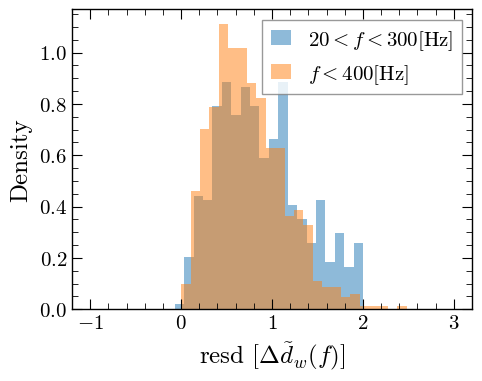

In [14]:
fig, ax = pf.create_plot()
ax.hist(dist1, bins=np.linspace(-1,2,30),alpha=0.5, density=True, label=r'$20<f<300$[Hz]')
ax.hist(dist2, bins=np.linspace(0,3,30), alpha=0.5, density=True, label=r'$f<400$[Hz]')
ax.set_xlabel(r'resd [$\Delta \tilde{d}_w(f)$]')
ax.set_ylabel('Density')
ax.legend()
pf.fix_plot([ax])